## MA934 Assignment 2

Author: Jabir Hussain (2007942)

---
Import the necessary libraries.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

### Task 1

This task looks to applying the finite difference method to a model for heat conduction across a metal fin. More specifically, let $T(x)$ be a function that represents the temperature along the metal fin at position $x$, where $x=0$ is the pot basin and $x = L$ is the tip. We define the temperature difference as $$\theta(x) = T(x) - T_{\infty}.$$ This satisfies the steady-state equation $$\theta '' - m^2\theta(x) = 0, x \in [0, L]$$ where $m^2 = \frac{Ph}{kA},$ where $P$ is the fin perimeter, $h$ is the convection coefficient, $k$ is the thermal conductivity and $A$ is the cross-sectional area.

The system has boundary conditions:

* At the pot end: $(T(0) = T_0)$ (known fixed temperature).
* At the handle tip: $(T'(L) = 0)$ (insulated end and thus no heat flux).

The system has the analytical solution derived from the ODE:
$$
\theta(x) = C_1 \cosh[m(L - x)] + C_2 \sinh[m(L - x)]
$$
Constants $(C_1, C_2)$ are chosen to satisfy the boundary conditions.


---


#### 1.3.1. A pot with a handle
We consider an aluminium pot with a handle of length 20cm, which is 3cm wide, and $\frac{1}{2}$cm thick. The pot is exposed to room air at 25 degrees, and the convection coeﬀicient is 5W/$m^2$ degrees C. The thermal
conductivity of aluminium is $k$ = 237W/m degrees C. The handle is insulated at its end.

To find the analytical solution, we apply the boundary conditions to find constants $C_1, C_2$. Firstly, we use the insulated tip condition $T'(L) = 0$. Differentiating the general solution gives the equation $$\theta '(x) = -mC_1 \sinh[m(L-x)] - mC_2\cosh[m(L-x)].$$ Evaluating this at $x=L$ gives $$\theta '(L) = -mC_1 \sinh(0) - mC_2\cosh(0)$$ $$ = -m(0) - mC_2$$ $$= -mC_2 = 0 \implies C_2 = 0$$

We then apply the base condition $T(0) = T_0$. Evaluating $x=0$ yields $$\theta(0) = C_1\cosh(mL) = \theta_0$$ $$\implies C_1 = \frac{\theta_0}{\cosh(mL)}$$

Substituting both constants into the general solution gives the final analytical solution $$\theta(x) = \theta_0 \frac{\cosh[m(L-x)]}{\cosh(mL)}$$

As $\theta(x) = T(x) - T_{\infty}$, we find that $$T(x) = T_{\infty} + (T_0 - T_{\infty}\frac{\cosh[m(L-x)]}{\cosh(mL)}$$.

Substituting in all the variable values, we find that cross-sectional area $A = 0.03 \times 0.005 = 1.5 \times 10^{-4}$, fin perimeter $P = 2(0.03+0.005) = 0$.

We then calculate $m$:
$$m = \sqrt{\frac{Ph}{kA}} = \sqrt{\frac{0.07 \times 5}{237 \times 1.5 \times 10^{-4}}} \approx 3.138 \text{m}^{-1}$$
$$\cosh(mL)=\cosh(3.138×0.20) \approx 1.204.$$

The numerical temperature profile is $$T(x) = 25+75\frac{\cosh(3.138(0.20-x))}{1.204}.$$

Assuming the end of the handle acts as a fine, with a surface side temperature of 100 degrees celsius, the temperature at the end of the handle is $T(L) = 25+\frac{75}{1.204} = 87.292$ degrees celsius.

---

We will now derive a finite difference approximation for the problem. The differential equation is valid for the domain $x \in [0, L]$ with boundary conditions $\theta(0) = \theta_0, \theta '(L) = 0$.

Firstly, we divide the domain into $N$ equidistant segments where $\Delta x = \frac{L}{N}$. This generates grid points $$x_i = i\Delta x, i = 0,1,...,N $$ where $\theta_i \approx \theta(x_i)$.

We can derive the finite difference approximation for the second derivative using a Taylor series expansion about $x_i$.

$$
\theta(x_{i+1}) = \theta(x_i) + \Delta x,\theta'(x_i) + \frac{\Delta x^2}{2}\theta''(x_i) + \frac{\Delta x^3}{6}\theta^{(3)}(x_i) + \frac{\Delta x^4}{24}\theta^{(4)}(x_i) + \mathcal{O}(\Delta x^5)
$$

$$
\theta(x_{i-1}) = \theta(x_i) - \Delta x,\theta'(x_i) + \frac{\Delta x^2}{2}\theta''(x_i) - \frac{\Delta x^3}{6}\theta^{(3)}(x_i) + \frac{\Delta x^4}{24}\theta^{(4)}(x_i) + \mathcal{O}(\Delta x^5)
$$

Adding these two equations eliminates the first-derivative terms:

$$
\theta(x_{i+1}) + \theta(x_{i-1}) = 2\theta(x_i) + \Delta x^2,\theta''(x_i) + \frac{\Delta x^4}{12}\theta^{(4)}(x_i) + \mathcal{O}(\Delta x^6)
$$

Rearranging for $\theta''(x_i)$ gives the central difference approximation:

$$
\theta''(x_i) = \frac{\theta_{i+1} - 2\theta_i + \theta_{i-1}}{\Delta x^2} - \frac{\Delta x^2}{12}\theta^{(4)}(x_i) + O(\Delta x^4)
$$

The leading error term is proportional to $\Delta x^2$, so this scheme is second-order accurate. We substitute this into our finite difference equation, giving $$ \theta ''(x_i) - m^2\theta(x_i)$$ $$= \frac{\theta_{i+1} - 2\theta_i + \theta_{i-1}}{\Delta x^2} - m^2\theta_i = 0$$

---



Rearranging,

$$
\theta_{i-1} - (2 + m^2\Delta x^2)\theta_i + \theta_{i+1} = 0.
$$

For each node $x_i$, we get a linear equation
linking $\theta_{i-1}$, $\theta_i$, and $\theta_{i+1}$.
Collecting all $(N-1)$ such equations yields a tridiagonal system of the form

$$
A\boldsymbol{\theta} = \boldsymbol{b},
$$

where $A$ is a sparse and banded matrix.


In [2]:
def fin_solver(N, L, m, theta_0, solver="numpy"):
    # assertions for sanity checks
    assert isinstance(N, int) and N > 2, "N must be an integer greater than 2 (at least 3 grid points)"
    assert L > 0, "Fin length L must be positive"
    assert m > 0, "Parameter m must be positive (derived from physical constants)"
    assert np.isfinite(theta_0), "Base temperature theta_0 must be a finite number"
    assert solver in ("numpy", "thomas"), "Solver must be 'numpy' or 'thomas'"

    dx = L / N
    x  = np.linspace(0, L, N+1)

    a = np.ones(N-1) # subdiagonal
    b = -(2 + (m*dx)**2) * np.ones(N-1)  # main diagonal
    c = np.ones(N-1) # superdiagonal
    rhs = np.zeros(N-1)
    rhs[0] = -theta_0

    # theta_N = theta_{N-1}
    a[-1] = 1.0
    b[-1] = -(1 + (m*dx)**2)
    c[-1] = 0.0

    if solver == "numpy":
        # Build full matrix
        A = np.zeros((N-1, N-1))
        np.fill_diagonal(A, b)
        np.fill_diagonal(A[1:], a[1:])
        np.fill_diagonal(A[:, 1:], c[:-1])
        theta_int = np.linalg.solve(A, rhs)

    elif solver == "thomas":
        # Thomas algorithm (forward elimination + back substitution)
        # We work directly on a,b,c,rhs (in-place)
        n = len(b)
        for i in range(1, n):
            w = a[i] / b[i-1]
            b[i] -= w * c[i-1]
            rhs[i] -= w * rhs[i-1]
        theta_int = np.zeros(n)
        theta_int[-1] = rhs[-1] / b[-1]
        for i in range(n-2, -1, -1):
            theta_int[i] = (rhs[i] - c[i] * theta_int[i+1]) / b[i]

    else:
        raise ValueError("solver must be 'numpy' or 'thomas'")

    theta = np.zeros(N+1)
    theta[0] = theta_0
    theta[1:N] = theta_int
    theta[N] = theta[N-1]
    return x, theta


The implementation above allows the user to set their own parameters, but also declare a choice of solver: the `numpy.linalg.solve` method and the `thomas` solver. The Thomas algorithm is a linear system solver specifically for tridiagonal coefficient matrices. (www.cfd-online.com. (n.d.).) The method is as follows:
* Forward sweep: change coefficients of main diagonal and right hand side to eliminate subdiagonal.
* Backward substitution: find unknowns starting with the last equation.

Given the tridiagonal formatting of the equation, the algorithm works well for this specific case. With a time complexity of $O(N)$ as opposed to `linalg.solve`'s $O(N^3)$, for large values of $N$ there is a considerable difference in performance.

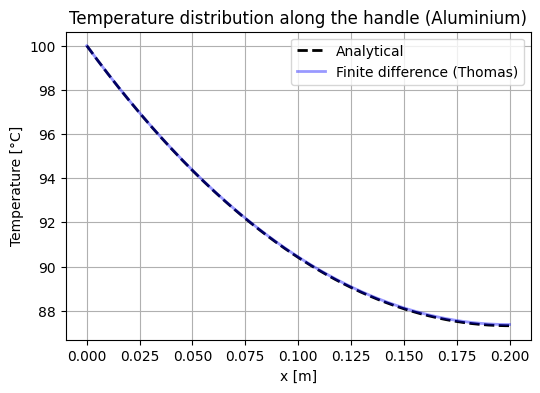

In [3]:
# Analytical solution
x = np.linspace(0, 0.2, 200)
theta_analytical = 75 * np.cosh(3.138 * (0.2 - x)) / np.cosh(3.138 * 0.2)

# Numerical (reuse from before)
x_fd, theta_fd = fin_solver(N=200, L=0.2, m=3.138, theta_0=75, solver="thomas")

# Plot
plt.figure(figsize=(6,4))
plt.plot(x, 25 + theta_analytical, 'k--', lw=2, label="Analytical")
plt.plot(x_fd, 25 + theta_fd, color='blue', alpha=0.4, lw=2, label="Finite difference (Thomas)")
plt.xlabel("x [m]")
plt.ylabel("Temperature [°C]")
plt.title("Temperature distribution along the handle (Aluminium)")
plt.legend()
plt.grid(True)
plt.show()


The curve above demonstrates that the solver function matches the analytical solution.

The function below, `compare_solvers`, calculates the maximum error given by $$\text{max error} = \text{max}_i |\theta_i^{(FD)} - \theta(x_i)|$$ where $\theta_i^{(FD)}$ is the finite approximate value.

If the `timing` parameter is set to true, it calculates the runtime of the solver for each value $N$. This was implemented to highlight the Thomas algorithm efficiency.

In [4]:
def compare_solvers(N_values, L, m, theta0):
    thomas_result = []
    numpy_results = []

    for solver in ["thomas", "numpy"]:
        for N in N_values:
            start = time.perf_counter()
            x, theta_fd = fin_solver(N, L, m, theta0, solver=solver)
            runtime = time.perf_counter() - start

            theta_exact = theta0 * np.cosh(m*(L - x)) / np.cosh(m*L)
            max_error = np.max(np.abs(theta_fd - theta_exact))

            if solver == "thomas":
                thomas_result.append((N, L/N, max_error, runtime))
            else:
                numpy_results.append((N, L/N, max_error, runtime))

    # Convert to arrays for plotting
    thomas_result = np.array(thomas_result)
    numpy_results = np.array(numpy_results)

    # Extract columns
    delta_x_thomas, error_thomas, runtime_thomas = thomas_result[:,1], thomas_result[:,2], thomas_result[:,3]
    delta_x_numpy, error_numpy, runtime_numpy = numpy_results[:,1], numpy_results[:,2], numpy_results[:,3]

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.loglog(delta_x_thomas, error_thomas, 'o-', label='Thomas', base=10)
    plt.loglog(delta_x_numpy, error_numpy, 's--', label='NumPy')
    plt.loglog(delta_x_thomas, error_thomas[0]*(delta_x_thomas/delta_x_thomas[0])**2, 'k:', label='$O(Δx^2)$')
    plt.gca().invert_xaxis()
    plt.xlabel('$Δx$')
    plt.ylabel('max error')
    plt.title('Convergence of Finite Difference Scheme')
    plt.grid(True, which='both', ls=':')
    plt.legend()

    plt.subplot(1,2,2)
    plt.loglog(thomas_result[:,0], runtime_thomas, 'o-', label='Thomas')
    plt.loglog(numpy_results[:,0], runtime_numpy, 's--', label='NumPy')
    plt.xlabel('N (number of grid intervals)')
    plt.ylabel('Runtime [s]')
    plt.title('Runtime scaling with N')
    plt.grid(True, which='both', ls=':')
    plt.legend()

    plt.tight_layout()
    plt.show()

    return thomas_result, numpy_results


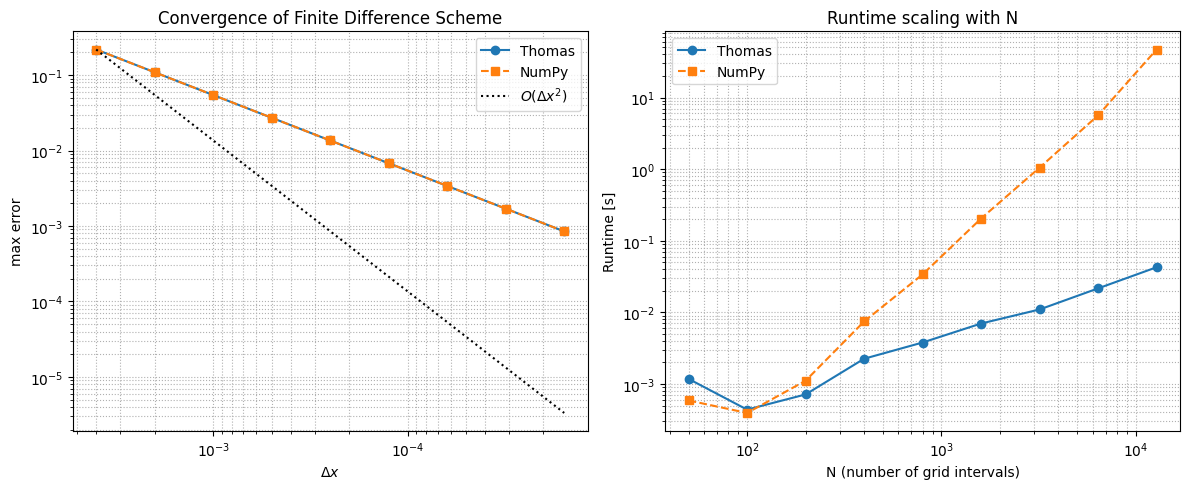

In [5]:
N_values = [50, 100, 200, 400, 800, 1600, 3200, 6400, 12800]
results_th, results_np = compare_solvers(N_values, L=0.2, m=3.138, theta0=75)

  From the figures above, we can draw the following conclusions:
  * As N grows, the maximum error decreases monotonically. This is as expected, with the convergence rate matching that of a theoretical second-order central difference setup.
  * The runtime of the Thomas algorithm is significantly faster, highlighting the O(N) complexity.

  ---

  


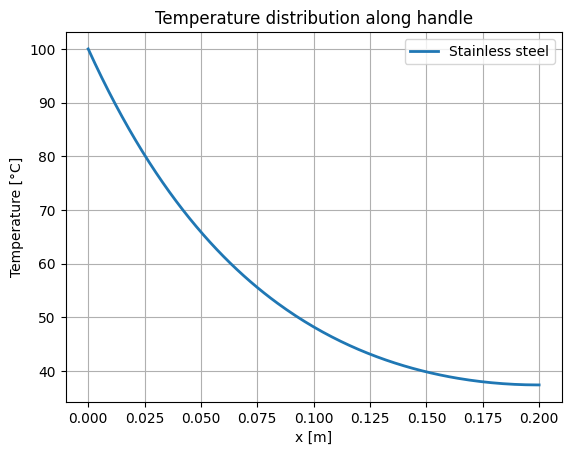

In [6]:
h = 5
w = 0.03
t = 0.005
P = 2 * (w + t)
A = w * t
# stainless steel specific
k_ss = 15
m_ss = np.sqrt(h * P / (k_ss * A))
x_ss, theta_ss = fin_solver(N=200, L=0.2, m=m_ss, theta_0=75, solver="thomas")
plt.plot(x_ss, 25 + theta_ss, label="Stainless steel", lw=2)
plt.xlabel("x [m]")
plt.ylabel("Temperature [°C]")
plt.title("Temperature distribution along handle")
plt.legend()
plt.grid(True)
plt.show()



---




### Task 2 - Numerical Integration

This task looks to solve non-linear integral problems, specifically Hammerstein equations. By fixing the integral boundaries, we get $$y(s) = h(s) + \int_0^1 K(s, t) g(y(t)) dt$$. To solve this, we must compute approximations $y_k \approx y(t_k)$m for $k = 0,1,...,N$. The root of a function $F: \mathbb{R}^N \rightarrow \mathbb{R}^N$ will be given by the vector of unknowns $\vec{y} = (y_0, ..., y_N)$

**Part A**:

We will use a quadrature rule to discretise the integral, with weights $\omega_k$ and nodes $t_k \in [0,1]$:

$$y(s) \approx h(s) + \sum_{k=0}^N \omega_k K(s, t_k)g(y_k)$$

We evaluate the discretised equation as specific s-values $s=t_l$ for $j = 0,1,...,N$. This gives the form $$y(t_l) = h(t_l) + \sum_{k=0}^N \omega_k K(t_l, t_k)g(y_k)$$ $$ = y_l = h(t_l) + \sum_{k=0}^N \omega_k K(t_l, t_k)g(y_k)$$

Setting the equation equal to 0, we get the vector function $$F_l(\vec{y}) = y_l - h(t_l) - \sum_{k=0}^N \omega_k K(t_l, t_k)g(y_k) = 0$$.

This gives the vector form $$F(\vec{y}) = 0, \vec{y} = (y_0, y_1, ..., y_N)^T.$$ This system of equations is solveable using Newton's method.

Newton's method iteratively solves a set of equations by the formula $$
\tilde{y}^{(m+1)} = \tilde{y}^{(m)} - [DF(\tilde{y}^{(m)})]^{-1}\,F(\tilde{y}^{(m)}),
$$ where $DF(\vec{y})$ is the Jacobian. Each Jacobian entry is given by

$$\frac{\partial F_l}{\partial y_j} = \frac{\partial}{\partial y_j}(y_l - h(t_l) - \sum_{k=0}^N \omega_k K(t_l, t_k)g(y_k)$$ $$= \delta_{lj} - \omega_j K(t_l, t_j)g'(y_j)$$ $$= [DF(\vec{y}^m)]_{l,j}$$

Since we have the equations for  $( F_l(\tilde{y}) )$ and its Jacobian $( DF(\tilde{y}) )$, we can apply Newton’s method iteratively:

$$
DF(\tilde{y}^{(m)}) , \Delta \tilde{y}^{(m)} = -F(\tilde{y}^{(m)}),
$$

$$
\tilde{y}^{(m+1)} = \tilde{y}^{(m)} + \Delta \tilde{y}^{(m)}.
$$

For each iteration:

1. $F(\tilde{y}^{(m)})$ is found by the quadrature approximation:
   $$
   F_l(\tilde{y}^{(m)}) = y_l^{(m)} - h(t_l) - \sum_{k=0}^N \omega_k K(t_l, t_k) g(y_k^{(m)}),
   $$
2. The Jacobian elements are calculated via:
   $$
   [DF(\tilde{y}^{(m)})]*{l,j} = \delta*{lj} - \omega_j K(t_l, t_j) g'(y_j^{(m)}),
   $$
3. The linear system is solved for $\Delta \tilde{y}^{(m)}$
4. The update step is applied.

This is repeated until there is convergence for a given tolerance value.


**Part B**:

I decided to deviate slightly from the provided approach. Rather than using a standard Python class, I opted for a dataclass. Dataclasses remove the boilerplate of having to call the `staticmethod` decorator for each function, as they use regular functions. It acts as a custom data structure which can be passed as an argument. It allows the user to pass different functions are parameters, serving as a template for this problem.

In [7]:
from dataclasses import dataclass

@dataclass
class Problem:
  y0: float
  K: callable # kernel K(s,t)
  g: callable # nonlinear g(y)
  dg: callable # derivative g'(y)
  h: callable # h(s)
  exact_sol: callable = None # optional exact solution

def F(y, t, omega, problem: Problem):
  # Discretised Hammerstein
  N = len(t)
  Fv = np.zeros(N)
  for l in range(N):
    s = t[l]
    Fv[l] = y[l] - problem.h(s) - np.sum(omega * problem.K(s, t) * problem.g(y))
  return Fv

def DF(y, t, omega, problem: Problem):
  # jacobian DF(y)
  # using numpy's broadcasting we can do a vectorised calculation of the
  # Jacobian; it's still O(N^2) but we get to use the C-level operations from Numpy
  T_l, T_j = np.meshgrid(t, t, indexing="ij")
  K_matrix = problem.K(T_l, T_j)
  g_dash = problem.dg(y)

  J = np.eye(len(t)) - K_matrix * (omega * g_dash)[np.newaxis, :]

  return J

def q2_solver(problem: Problem, quadrature, tol=1e-10, max_iter=100, verbose=False):
  # set verbose argument to True to see outputs.
  t, omega = quadrature()
  y = np.full_like(t, problem.y0, dtype=float)
  converged = False

  for n in range(max_iter):
    Fv = F(y, t, omega, problem)
    J = DF(y, t, omega, problem)
    delta = np.linalg.solve(J, -Fv)
    y += delta

    if np.linalg.norm(delta) < tol:
      converged = True
      if verbose:
        print(f"Convergence at {n+1} iterations.")
        break

  if not converged and verbose:
    print(f"No convergence at {max_iter} iterations.")

  return t, y

def trapezoidal(N=65, a=0, b=1):
    assert N >= 2, "N must be at least 2 for trapezoidal rule."

    t = np.linspace(a, b, N)
    h = (b - a) / (N - 1)
    omega = np.ones(N) * h
    omega[0] /= 2
    omega[-1] /= 2

    assert np.isclose(np.sum(omega), (b - a), rtol=1e-12), "Trapezoidal weights do not sum to interval length!"
    assert np.all(omega > 0), "Trapezoidal weights must be positive."

    return t, omega

def simpson(N=65, a=0, b=1):
    if N % 2 == 0:
        N += 1
        print(f"Adjusted N to {N} (Simpson’s rule requires an odd number of points).")

    t = np.linspace(a, b, N)
    h = (b - a) / (N - 1)
    omega = np.ones(N)
    omega[1:-1:2] = 4
    omega[2:-2:2] = 2
    omega *= h / 3

    assert np.isclose(np.sum(omega), (b - a), rtol=1e-12), "Simpson weights do not sum to interval length!"
    assert np.all(omega > 0), "Simpson weights must be positive."

    return t, omega



**Part C**

We can instantiate the dataclass and call the solver function. The `verbose` flag is set to False by default; set it to `True` to see the convergence output. Whilst it's automatically set to False in the function setup, I included it below for ease of editing.

In [8]:
problem = Problem(
    y0 = 4.0,
    K = lambda s, t: 3*s*t,
    g = lambda y: y**3,
    dg = lambda y: 3*y**2,
    h = lambda s: (1/3)*(3*np.exp(s) - 2*s*np.exp(3) - s),
    exact_sol = lambda s: np.exp(s)
)

t_trap, y_trap = q2_solver(problem, lambda: trapezoidal(N=65), verbose=False)
t_simp, y_simp = q2_solver(problem, lambda: simpson(N=65), verbose=False)

We can compute the RMSE of the two quadrature solutions and the experimental order of convergence (EOC). The EOC is found by the formula

$$
p = \frac{\log\left( \frac{|I_{h_1}(f) - I(f)|}{|I_{h_2}(f) - I(f)|} \right)}{\log\left( \frac{h_1}{h_2} \right)}.
$$

In [9]:
Ns = [(2**i) + 1 for i in range(1, 10)]
err_trap, err_simp = [], []

for N in Ns:
    # Trapezoidal rule
    t, y = q2_solver(problem, lambda: trapezoidal(N), verbose=False)
    eN = np.sqrt(np.mean((y - problem.exact_sol(t))**2))
    err_trap.append(eN)

    # Simpson rule
    t, y = q2_solver(problem, lambda: simpson(N), verbose=False)
    eN = np.sqrt(np.mean((y - problem.exact_sol(t))**2))
    err_simp.append(eN)

def compute_EOC(Ns, errors):
    eocs = []
    for i in range(len(Ns) - 1):
        h1, h2 = 1/Ns[i], 1/Ns[i+1]
        e1, e2 = errors[i], errors[i+1]
        p = np.log(e1/e2) / np.log(h1/h2)
        eocs.append(p)
    return np.array(eocs)

Plotting the results of the true solution with the quadrature based solutions, we can conclude the quadrature solutions work effectively.

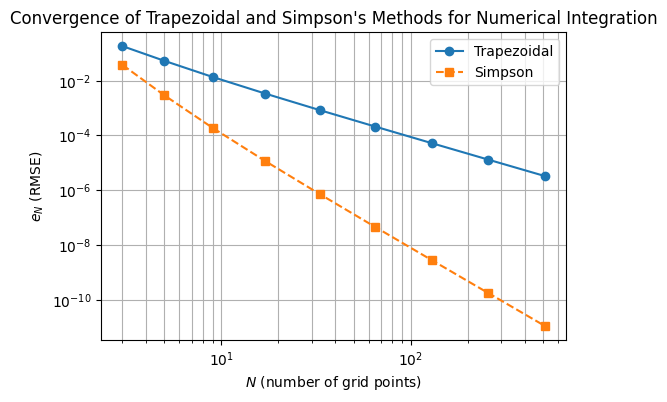

Mean EOC (Trapezoidal): 2.14
Mean EOC (Simpson): 4.30


In [10]:
plt.figure(figsize=(6,4))
plt.loglog(Ns, err_trap, 'o-', label="Trapezoidal")
plt.loglog(Ns, err_simp, 's--', label="Simpson")
plt.xlabel("$N$ (number of grid points)")
plt.ylabel("$e_N$ (RMSE)")
plt.title("Convergence of Trapezoidal and Simpson's Methods for Numerical Integration")
plt.grid(True, which="both")
plt.legend()
plt.show()

EOC_trap = compute_EOC(Ns, err_trap)
EOC_simp = compute_EOC(Ns, err_simp)

print(f"Mean EOC (Trapezoidal): {np.mean(EOC_trap):.2f}")
print(f"Mean EOC (Simpson): {np.mean(EOC_simp):.2f}")

From the figure above, it shows that the use of Simpson's rule for quadrature converges with $\approx O(h^4)$, which significantly faster than the composite trapezoidal rule $\approx O(h^2)$. These convergence rates were found using the `compute_EOC` method, where the Trapezoidal has EOC 2.14 and the Simpson rule has EOC 4.30.


---


#### Task 3

We want to approximate the derivative of the product $((a(x)u'(x))')$.

Firstly, we define $\zeta(x)=a(x)u'(x)$.
By the central difference formula, we use a half–step $(\delta=\tfrac{h}{2})$ at the midpoints $(x\pm \tfrac{h}{2})$. This gives us the equation

$$
\zeta'(x)\approx \frac{\zeta\left(x+\tfrac{h}{2}\right)-\zeta\left(x-\tfrac{h}{2}\right)}{h}.
$$

We evaluate the accuracy by taking the Taylor expansion up to the first error term.

$$
\zeta\left(x+\delta\right)=\zeta(x)+\delta,\zeta'(x)+\frac{\delta^{2}}{2}\zeta''(x)+\frac{\delta^{3}}{6}\zeta^{(3)}(x)+O(\delta^{4}),
$$

$$
\zeta\left(x-\delta\right)=\zeta(x)-\delta,\zeta'(x)+\frac{\delta^{2}}{2}\zeta''(x)-\frac{\delta^{3}}{6}\zeta^{(3)}(x)+O(\delta^{4}).
$$

By subtracting the two expansions, we cancel out the even powers, leaving only the odd terms.

$$
\zeta\left(x+\delta\right)-\zeta\left(x-\delta\right)=2\delta,\zeta'(x)+\frac{2\delta^{3}}{6}\zeta^{(3)}(x)+O(\delta^{5}).
$$

We then divide by $2\delta$, yielding the central difference approximation and its truncation error.

$$
\frac{\zeta\left(x+\delta\right)-\zeta\left(x-\delta\right)}{2\delta}=\zeta'(x)+\frac{\delta^{2}}{6}\zeta^{(3)}(x)+O(\delta^{4}).
$$

If we set $\delta=\tfrac{h}{2}$, we can convert the error term into $(O(h^{2}))$.

$$
\frac{\zeta\left(x+\tfrac{h}{2}\right)-\zeta\left(x-\tfrac{h}{2}\right)}{h}
=\zeta'(x)+\frac{h^{2}}{24}\zeta^{(3)}(x)+O(h^{4}).
$$

$$\zeta=a,u' \implies (\zeta'(x)=(a(x)u'(x))')$$

Replacing $\zeta$ by $(a,u')$ gives

$$
(a(x)u'(x))'
=\frac{a\left(x+\tfrac{h}{2}\right)u'\left(x+\tfrac{h}{2}\right)-a\left(x-\tfrac{h}{2}\right)u'\left(x-\tfrac{h}{2}\right)}{h}
+\frac{h^{2}}{24},(a,u')^{(3)}(x)+O(h^{4}).
$$

Thus, the midpoint central-difference has truncation error $(O(h^{2}))$.

By approximating each midpoint derivative $u'\left(x\pm\tfrac{h}{2}\right)$, we find that

$$
u'\left(x+\tfrac{h}{2}\right)\approx \frac{u(x+h)-u(x)}{h}+O(h^{2}), \qquad
u'\left(x-\tfrac{h}{2}\right)\approx \frac{u(x)-u(x-h)}{h}+O(h^{2}).
$$

Substituting these into the previous formula keeps the overall error at order $(h^{2})$:

$$  (a(x)u'(x))' = a\left(x+\tfrac{h}{2}\right)\frac{u(x+h)-u(x)}{h} - a\left(x-\tfrac{h}{2}\right)\frac{u(x)-u(x-h)}{h} - O(h^{2})$$


#### References:
www.cfd-online.com. (n.d.). Tridiagonal matrix algorithm - TDMA (Thomas algorithm) -- CFD-Wiki, the free CFD reference. [online] Available at: https://www.cfd-online.com/Wiki/Tridiagonal_matrix_algorithm_-_TDMA_(Thomas_algorithm). Date accessed: 11/11/2025.